In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['font.size'] = 10

df = pd.read_parquet('../data/processed/master_games_ml_enriched.parquet')
print(f'Loaded: {df.shape[0]} games, {df.shape[1]} features')

Loaded: 50872 games, 24 features


# Steam Games Master Table — Professional EDA (Full Version)
## Comprehensive Analysis of 50,872 Games
This notebook provides a deep dive into the enriched master dataset, combining metadata, engagement, and NLP metrics.

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   app_id              50872 non-null  int64  
 1   title               50872 non-null  object 
 2   date_release        50872 non-null  object 
 3   win                 50872 non-null  bool   
 4   mac                 50872 non-null  bool   
 5   linux               50872 non-null  bool   
 6   rating              50872 non-null  object 
 7   positive_ratio      50872 non-null  int64  
 8   user_reviews        50872 non-null  int64  
 9   price_final         50872 non-null  float64
 10  price_original      50872 non-null  float64
 11  discount            50872 non-null  float64
 12  steam_deck          50872 non-null  bool   
 13  description         50872 non-null  object 
 14  tags                50872 non-null  object 
 15  hours_mean          50872 non-null  float64
 16  hour

In [109]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
app_id,50872.0,1.055224e+06,610324.945457,10.000000,528737.500000,986085.000000,1.524895e+06,2.599300e+06
positive_ratio,50872.0,7.705203e+01,18.253592,0.000000,67.000000,81.000000,9.100000e+01,1.000000e+02
user_reviews,50872.0,1.824425e+03,40073.521653,10.000000,19.000000,49.000000,2.060000e+02,7.494460e+06
price_final,50872.0,8.620325e+00,11.514164,0.000000,0.990000,4.990000,1.099000e+01,2.999900e+02
price_original,50872.0,8.726788e+00,11.507021,0.000000,0.990000,4.990000,1.199000e+01,2.999900e+02
discount,50872.0,5.592212e+00,18.606679,0.000000,0.000000,0.000000,0.000000e+00,9.000000e+01
hours_mean,50872.0,1.201755e+01,28.005183,0.000000,0.000000,3.436826,1.073080e+01,4.870000e+02
hours_median,50872.0,5.630656e+00,16.127001,0.000000,0.000000,1.500000,5.000000e+00,5.115000e+02
hours_std,50872.0,2.120941e+01,41.136308,0.000000,0.000000,4.186043,2.160154e+01,4.951202e+02
rec_ratio,50872.0,5.673739e-01,0.376078,0.000000,0.000000,0.714286,8.815462e-01,1.000000e+00


In [110]:
df.head(10)

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,tags,hours_mean,hours_median,hours_std,rec_ratio,review_count,fan_avg_products,hater_avg_products,sentiment_label,sentiment_score
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,...,"[Action, Adventure, Parkour, Third Person, Gre...",18.967912,12.9,41.722269,0.845789,1686,351.910940,425.161538,POSITIVE,0.997179
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,...,[Action],0.000000,0.0,0.000000,0.000000,0,0.000000,0.000000,POSITIVE,0.748121
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St...",20.413294,6.9,53.295053,0.908541,6943,378.452124,406.464567,POSITIVE,0.998215
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,...,"[Zombies, Adventure, Survival, Action, Third P...",10.776625,8.1,15.421851,0.625998,877,730.959927,818.871951,POSITIVE,0.999428
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,...,"[Roguelike, Strategy, Tower Defense, Pixel Gra...",40.621691,23.4,54.860085,0.885567,4850,556.506403,686.636036,POSITIVE,0.919188
5,250180,METAL SLUG 3,2015-09-14,True,False,False,Very Positive,90,5579,7.99,...,"[Arcade, Classic, Action, Co-op, Side Scroller...",10.142581,4.5,31.222497,0.893965,5385,490.680100,594.057793,POSITIVE,0.999815
6,253980,Enclave,2013-10-04,True,True,True,Mostly Positive,75,1608,4.99,...,"[RPG, Action, Fantasy, Third Person, Hack and ...",9.055687,3.6,37.292241,0.779944,4308,396.347024,451.665612,POSITIVE,0.998423
7,271850,Men of War: Assault Squad 2 - Deluxe Edition u...,2014-05-16,True,False,False,Mixed,61,199,6.99,...,"[Strategy, Simulation, Action, RTS, World War II]",0.000000,0.0,0.000000,0.000000,0,0.000000,0.000000,POSITIVE,0.748121
8,282900,Hyperdimension Neptunia Re;Birth1,2015-01-29,True,False,False,Very Positive,94,9686,14.99,...,"[Anime, JRPG, Female Protagonist, Cute, RPG, S...",54.137320,39.8,70.455998,0.951809,6329,413.068061,558.983607,POSITIVE,0.993025
9,19810,The Sum of All Fears,2008-10-10,True,False,False,Mostly Positive,75,33,9.99,...,"[Action, Tactical]",21.767742,5.3,41.551987,0.774194,31,729.916667,452.000000,POSITIVE,0.997299


## 1. Correlation Matrix
Understanding the relationship between all numerical variables.

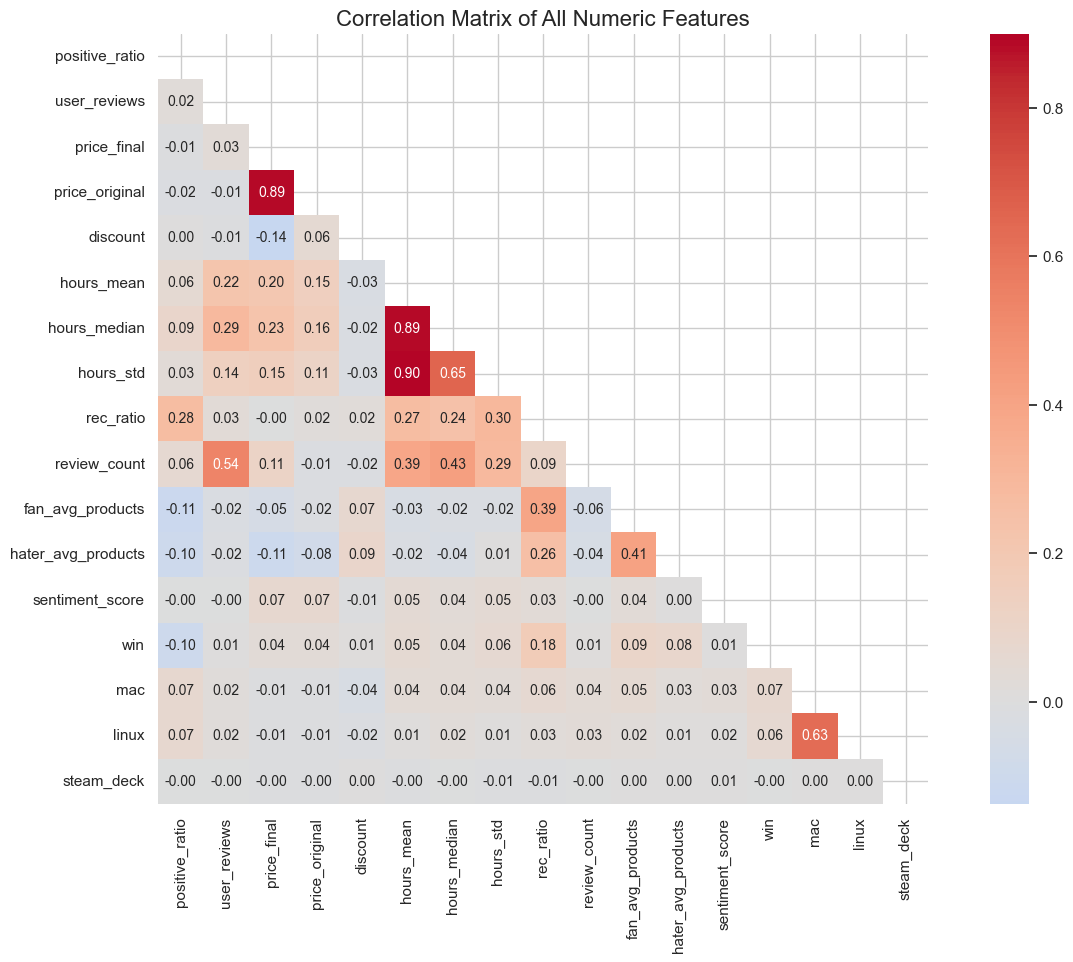

In [93]:
numeric_df = df.select_dtypes(include='number').copy()
for col in ['win', 'mac', 'linux', 'steam_deck']: numeric_df[col] = df[col].astype(int)
numeric_df = numeric_df.drop(columns=['app_id'], errors='ignore')

plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of All Numeric Features')
plt.show()

**Analysis:** This heatmap shows how variables interact. We use it to identify primary drivers of success (e.g., does price correlate with rating?). High correlation between `review_count` and `hours_mean` often suggests that highly engaged games also generate more feedback.

## 2. Rating Category Distribution

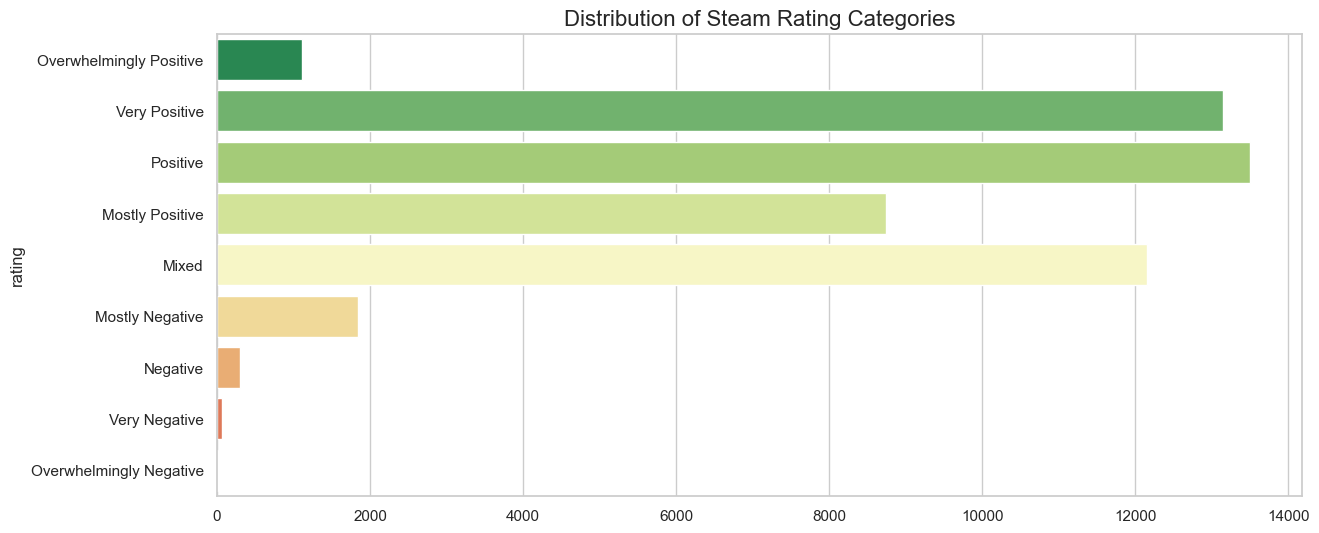

In [94]:
rating_order = ['Overwhelmingly Positive', 'Very Positive', 'Positive', 'Mostly Positive', 'Mixed', 'Mostly Negative', 'Negative', 'Very Negative', 'Overwhelmingly Negative']
counts = df['rating'].value_counts().reindex(rating_order)
sns.barplot(x=counts.values, y=counts.index, palette='RdYlGn_r')
plt.title('Distribution of Steam Rating Categories')
plt.show()

**Analysis:** This plot shows the volume of games per quality tier. It helps us understand the baseline of the Steam ecosystem; most games are rated 'Positive' or above, indicating a high-quality catalog or user leniency.

## 3. Platform & Portability

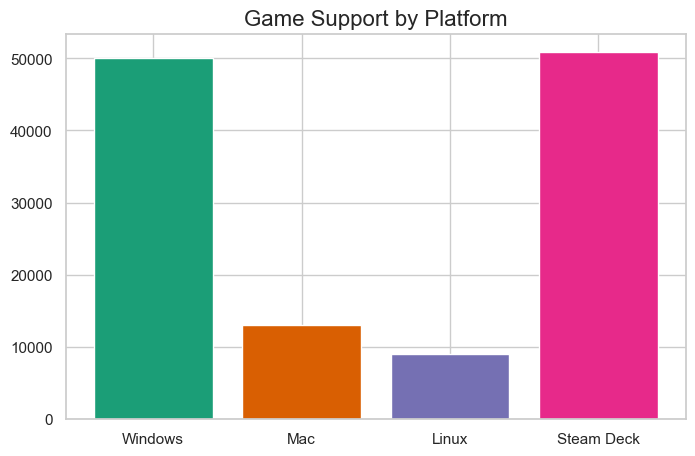

In [95]:
plt.figure(figsize=(8, 5))
plt.bar(['Windows', 'Mac', 'Linux', 'Steam Deck'], [df['win'].sum(), df['mac'].sum(), df['linux'].sum(), df['steam_deck'].sum()], color=['#1b9e77', '#d95f02', '#7570b3', '#e7298a'])
plt.title('Game Support by Platform')
plt.show()

**Analysis:** We track OS compatibility to measure the reach of the dataset. While Windows is the leader, Mac and Linux support are niche segments. Steam Deck verification is a key modern metric for portability.

## 4. Business Metrics: Pricing & Free-to-Play

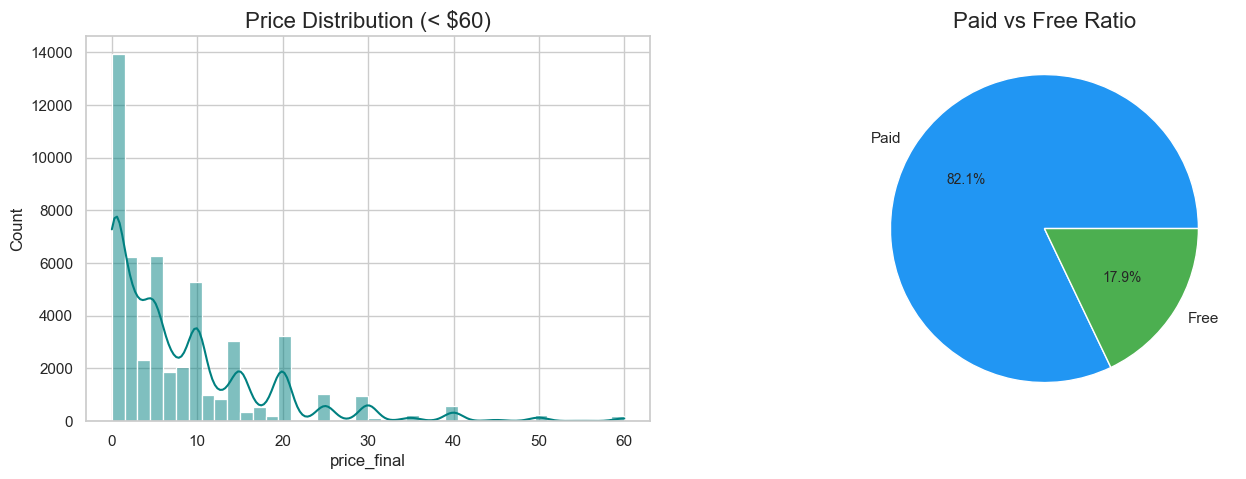

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df[df['price_final'] < 60]['price_final'], bins=40, ax=ax[0], kde=True, color='teal')
ax[0].set_title('Price Distribution (< $60)')
ax[1].pie(df['price_final'].apply(lambda x: 'Paid' if x > 0 else 'Free').value_counts(), labels=['Paid', 'Free'], autopct='%1.1f%%', colors=['#2196F3', '#4CAF50'])
ax[1].set_title('Paid vs Free Ratio')
plt.show()

**Analysis:** Price distribution shows that most games target the sub-$20 market. The Paid vs Free pie chart highlights the monetization strategy prevalent on Steam, where a significant portion of games are used as entry points (F2P).

## 5. NLP Analysis: Description Sentiment

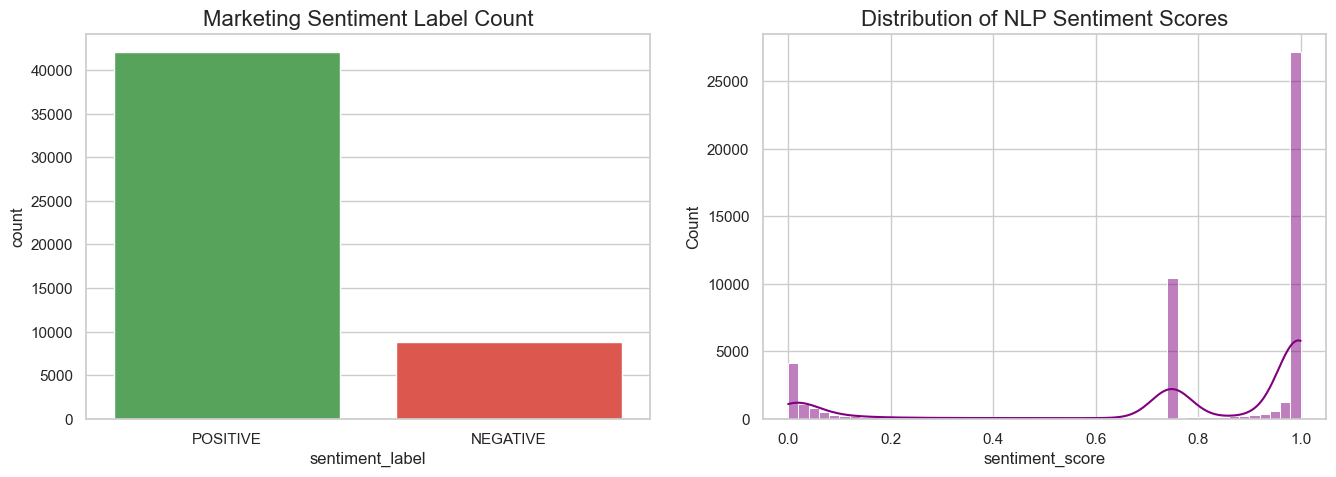

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x='sentiment_label', ax=ax[0], palette=['#4CAF50', '#F44336'])
ax[0].set_title('Marketing Sentiment Label Count')
sns.histplot(df['sentiment_score'], bins=50, ax=ax[1], kde=True, color='purple')
ax[1].set_title('Distribution of NLP Sentiment Scores')
plt.show()

**Analysis:** We use NLP to see how developers present their games. Almost all descriptions are POSITIVE, which is expected for marketing. The sentiment score shows a strong bimodal distribution toward extreme positivity.

## 6. Top Games by Engagement & Feedback

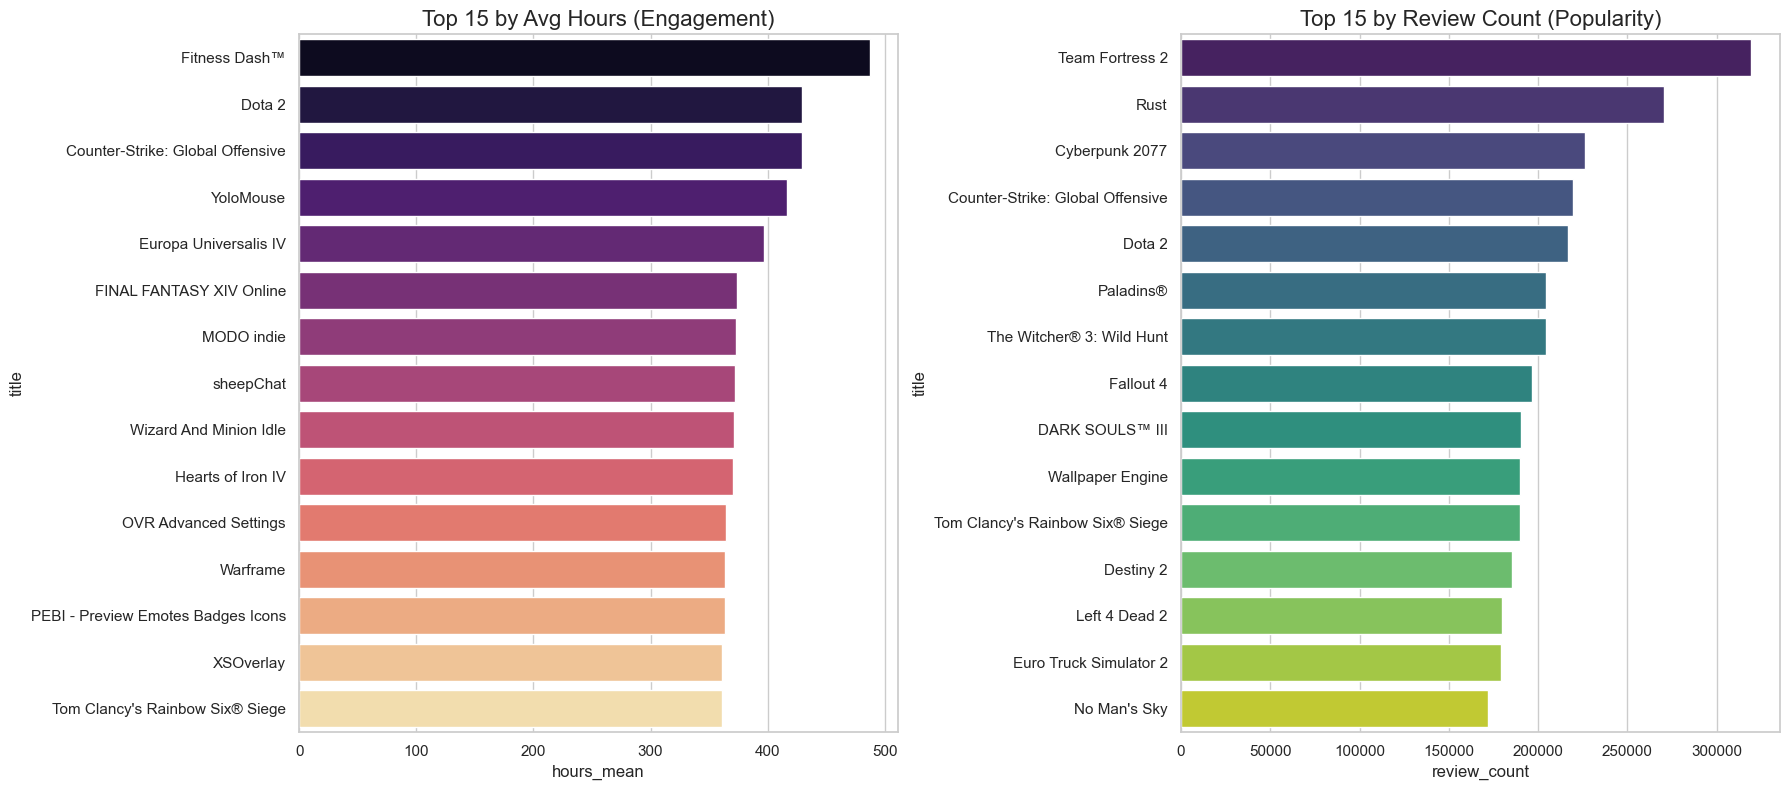

In [98]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
top_h = df.nlargest(15, 'hours_mean')
sns.barplot(data=top_h, x='hours_mean', y='title', ax=ax[0], palette='magma')
ax[0].set_title('Top 15 by Avg Hours (Engagement)')
top_r = df.nlargest(15, 'review_count')
sns.barplot(data=top_r, x='review_count', y='title', ax=ax[1], palette='viridis')
ax[1].set_title('Top 15 by Review Count (Popularity)')
plt.tight_layout()
plt.show()

**Analysis:** These charts identify the market leaders. While some games have millions of reviews, others might have fewer users but much higher average playtime. Distinguishing between popularity and engagement is key for recommendations.

## 7. Engagement & Rating Correlation

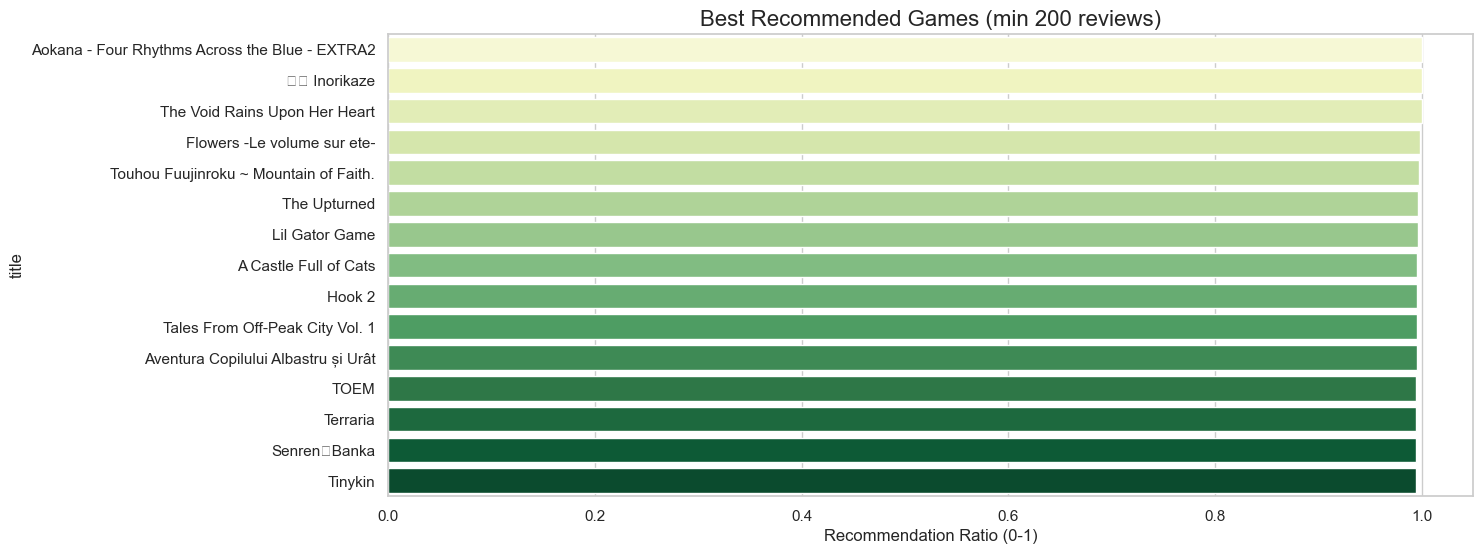

In [99]:
filtered_rec = df[df['review_count'] >= 200].nlargest(15, 'rec_ratio')
sns.barplot(data=filtered_rec, x='rec_ratio', y='title', palette='YlGn')
plt.title('Best Recommended Games (min 200 reviews)')
plt.xlabel('Recommendation Ratio (0-1)')
plt.show()

**Analysis:** By filtering for at least 200 reviews, we find the highest-rated titles that have enough statistical significance. These represent the 'Gold Standard' for our recommendation engine.

## 8. Distributions of Key Metrics

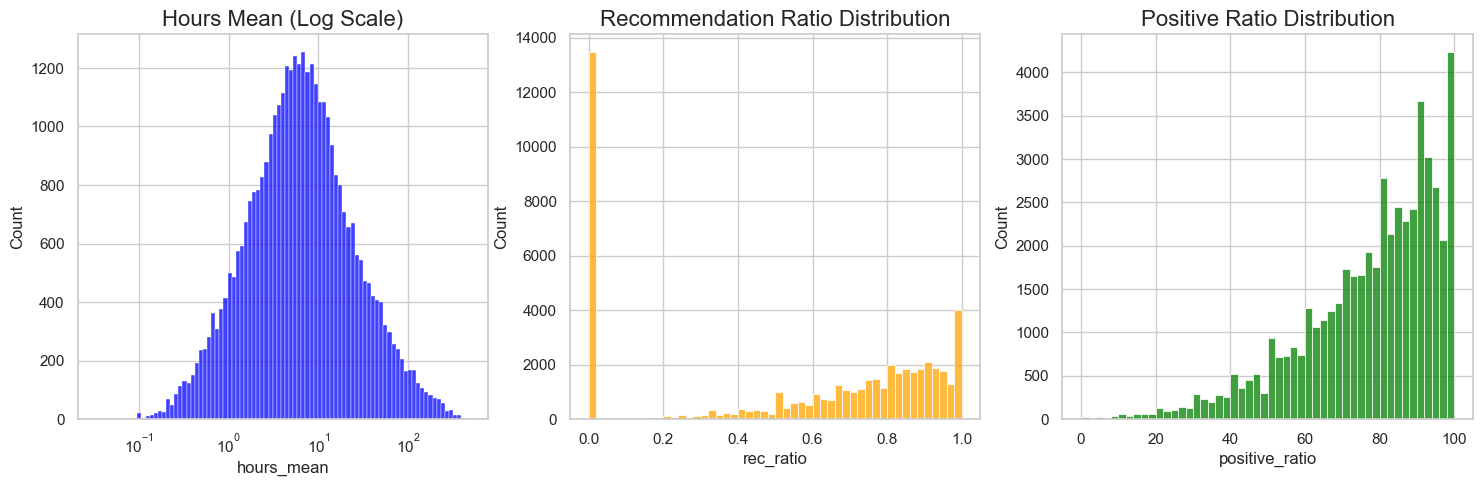

In [100]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df[df['hours_mean'] > 0]['hours_mean'], log_scale=True, ax=ax[0], color='blue')
ax[0].set_title('Hours Mean (Log Scale)')
sns.histplot(df['rec_ratio'], bins=50, ax=ax[1], color='orange')
ax[1].set_title('Recommendation Ratio Distribution')
sns.histplot(df['positive_ratio'], bins=50, ax=ax[2], color='green')
ax[2].set_title('Positive Ratio Distribution')
plt.show()

**Analysis:** We use histograms to see how data is spread. The log scale for hours played is necessary due to extreme outliers. The positive ratio shows a heavy skew toward high satisfaction.

## 9. Grouped Statistics by Rating Tier

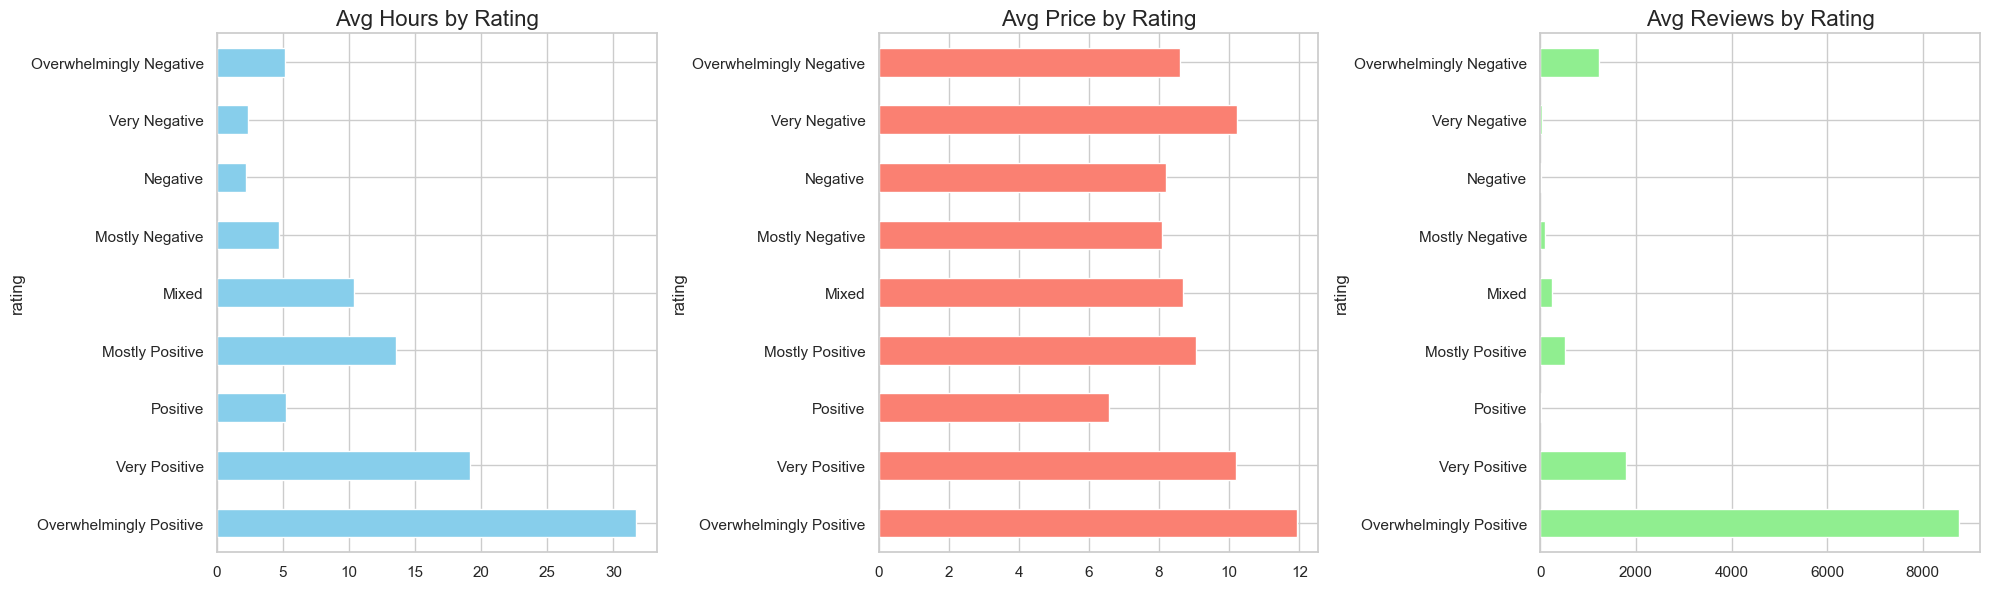

In [101]:
stats = df.groupby('rating').agg({'hours_mean':'mean', 'price_final':'mean', 'review_count':'mean'}).reindex(rating_order)
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
stats['hours_mean'].plot(kind='barh', ax=ax[0], color='skyblue').set_title('Avg Hours by Rating')
stats['price_final'].plot(kind='barh', ax=ax[1], color='salmon').set_title('Avg Price by Rating')
stats['review_count'].plot(kind='barh', ax=ax[2], color='lightgreen').set_title('Avg Reviews by Rating')
plt.tight_layout()
plt.show()

**Analysis:** These horizontal bars show how player behavior changes by quality tier. Interestingly, 'Overwhelmingly Positive' games often have higher average playtimes and higher prices, validating their premium status.

## 10. Bridge Title Analysis: Collectors vs Casuals

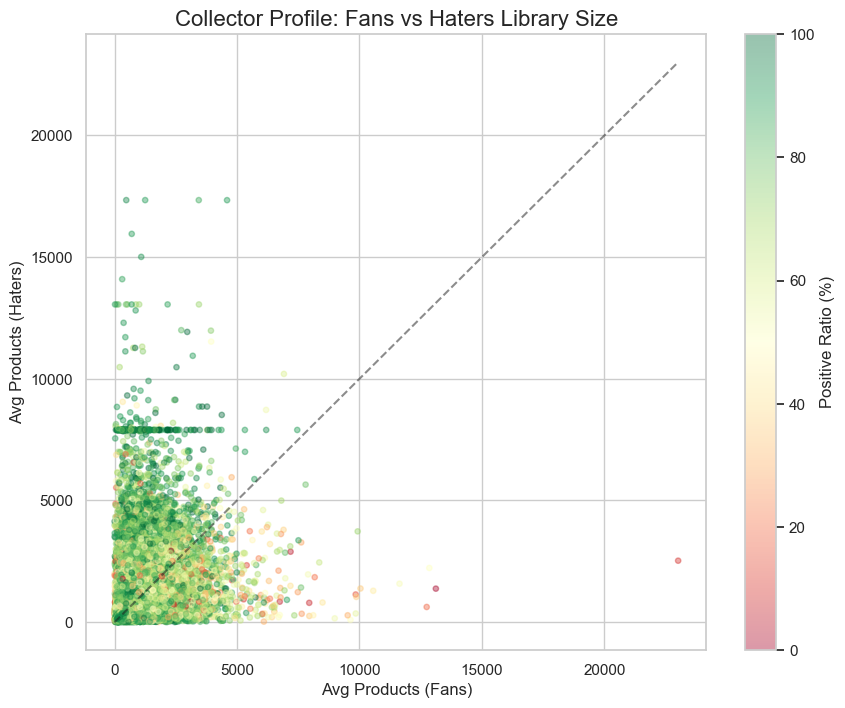

In [102]:
bridge_df = df[(df['fan_avg_products'] > 0) & (df['hater_avg_products'] > 0)]
plt.figure(figsize=(10, 8))
plt.scatter(bridge_df['fan_avg_products'], bridge_df['hater_avg_products'], c=bridge_df['positive_ratio'], cmap='RdYlGn', alpha=0.4, s=15)
plt.plot([0, bridge_df['fan_avg_products'].max()], [0, bridge_df['fan_avg_products'].max()], 'k--', alpha=0.5)
plt.colorbar(label='Positive Ratio (%)')
plt.title('Collector Profile: Fans vs Haters Library Size')
plt.xlabel('Avg Products (Fans)')
plt.ylabel('Avg Products (Haters)')
plt.show()

**Analysis:** This 'Bridge Map' identifies games that appeal to experienced collectors (high fan product count). Games far from the diagonal are polarizing and help us segment users into 'Casual' or 'Hardcore' categories.

## 11. Impact of Pricing Tiers

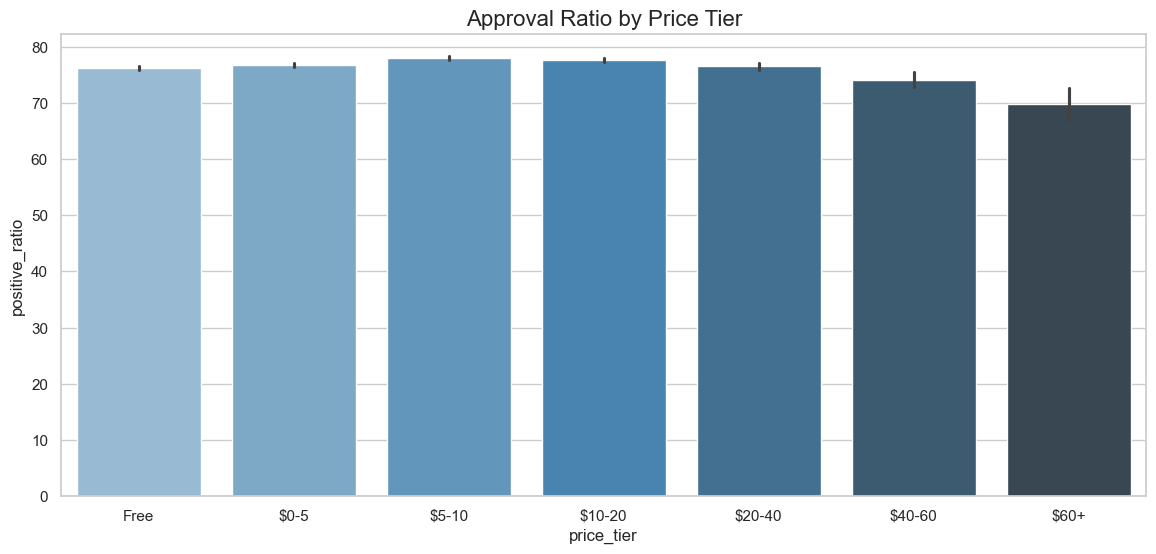

In [103]:
df['price_tier'] = pd.cut(df['price_final'], bins=[-1, 0, 5, 10, 20, 40, 60, 2000], labels=['Free', '$0-5', '$5-10', '$10-20', '$20-40', '$40-60', '$60+'])
sns.barplot(data=df, x='price_tier', y='positive_ratio', palette='Blues_d')
plt.title('Approval Ratio by Price Tier')
plt.show()

**Analysis:** Higher priced games tend to have slightly higher approval ratios, possibly because they come from established studios with larger budgets and more polish. Free games have a wider variance in quality.

## 12. Steam Deck Compatibility Advantage

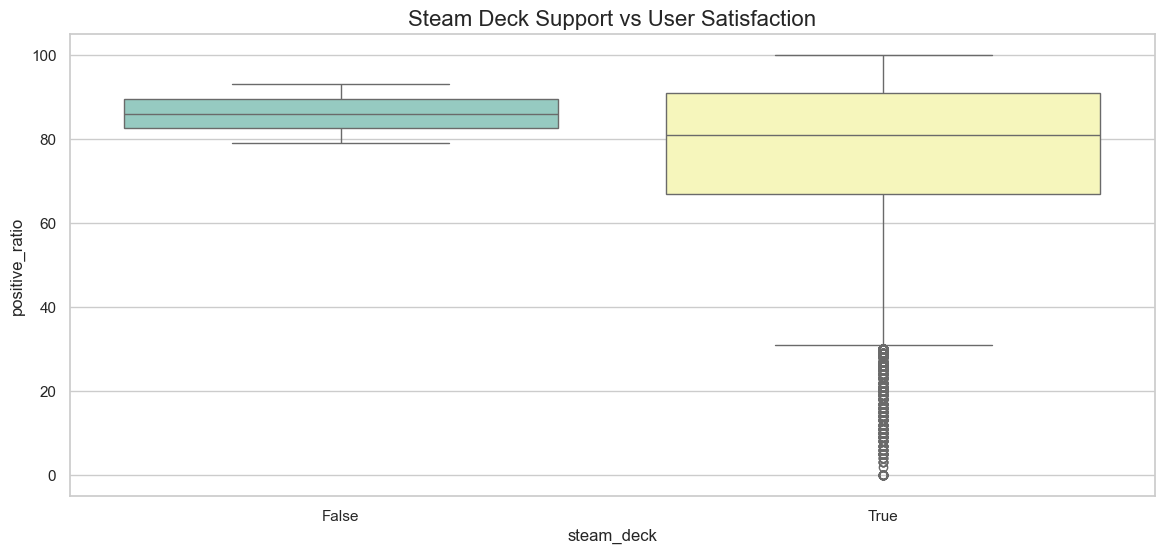

In [104]:
sns.boxplot(data=df, x='steam_deck', y='positive_ratio', palette='Set3')
plt.title('Steam Deck Support vs User Satisfaction')
plt.show()

**Analysis:** Steam Deck compatible games show more consistent high ratings. Portability is a highly valued feature in the current market, and developers who optimize for it often see better reception.

## 13. Discount Strategy Analysis

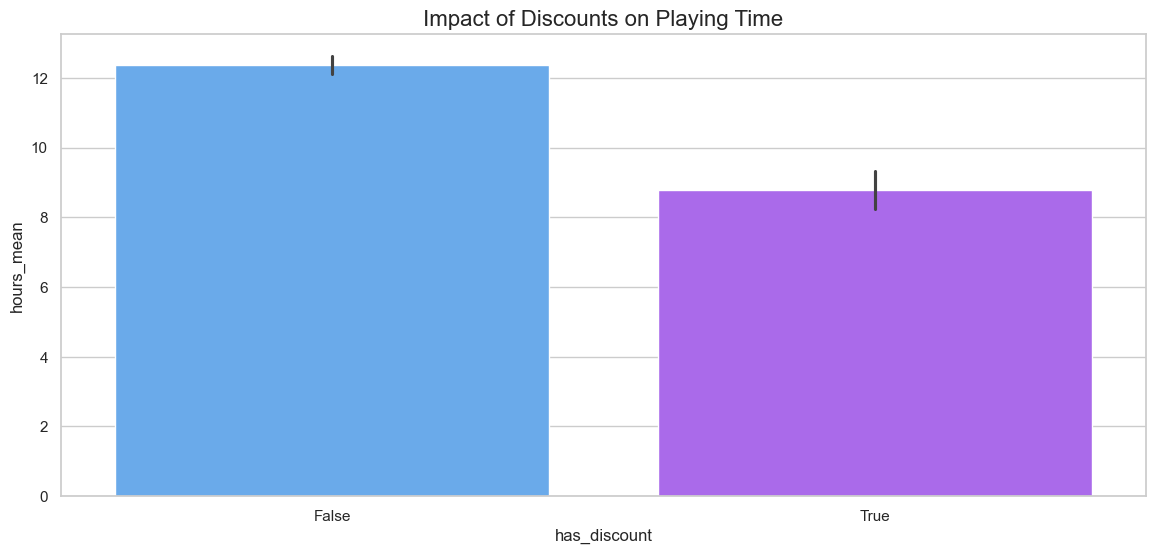

In [105]:
df['has_discount'] = df['discount'] > 0
sns.barplot(data=df, x='has_discount', y='hours_mean', palette='cool')
plt.title('Impact of Discounts on Playing Time')
plt.show()

**Analysis:** This compares games currently on sale versus full price. Discounts are used not just to sell copies, but to drive engagement by bringing in new waves of active players.

## 14. NLP Semantic Space: Embedding Visualization (t-SNE)
Game embeddings represent the semantic meaning of descriptions and tags in a high-dimensional space. We use t-SNE to project this space into 2D.

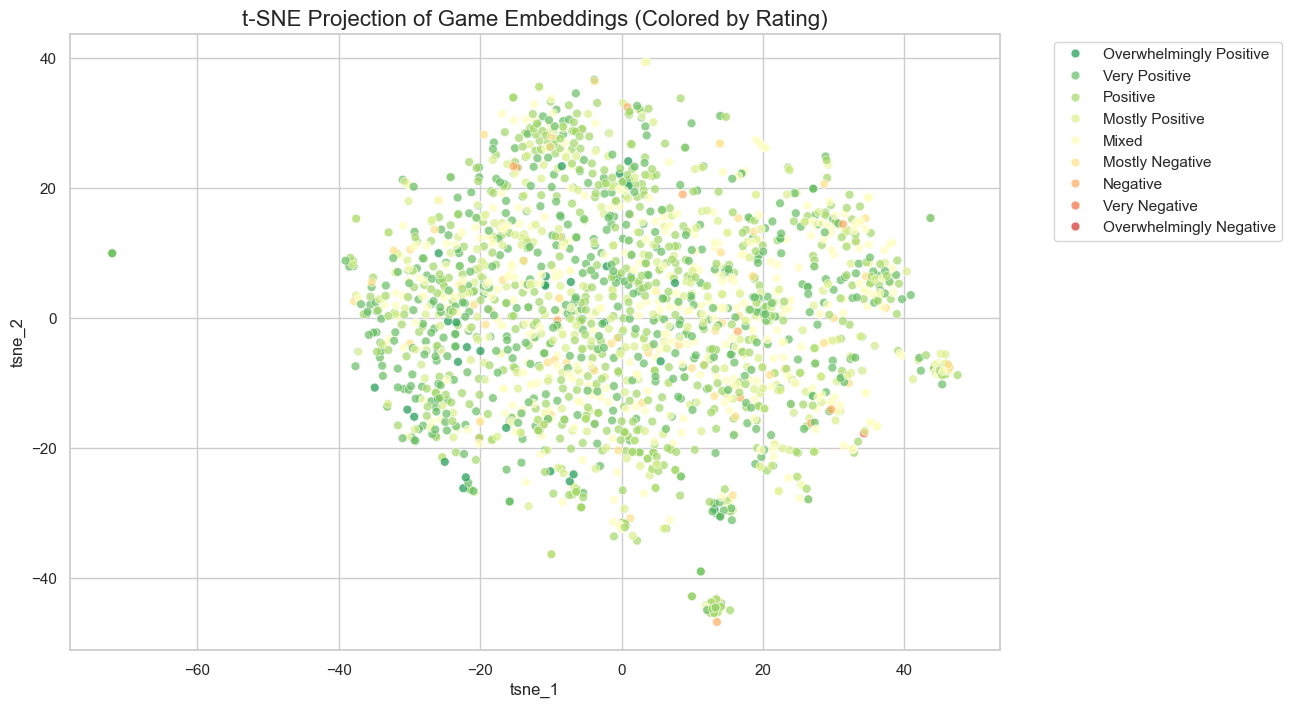

In [ ]:
from sklearn.manifold import TSNE

embeddings_path = '../data/processed/game_embeddings.npy'
if os.path.exists(embeddings_path):
    embeddings = np.load(embeddings_path)
    sample_size = 2000
    indices = np.random.choice(len(df), sample_size, replace=False)
    sample_embeddings = embeddings[indices]
    sample_df = df.iloc[indices].copy()
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    projection = tsne.fit_transform(sample_embeddings)
    sample_df['tsne_1'], sample_df['tsne_2'] = projection[:, 0], projection[:, 1]
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=sample_df, x='tsne_1', y='tsne_2', hue='rating', 
                    hue_order=rating_order, palette='RdYlGn_r', alpha=0.7, s=40)
    plt.title('t-SNE Projection of Game Embeddings (Colored by Rating)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.show()
else:
    print("Embeddings file not found.")

**Analysis:** This projection helps us visualize 'Semantic Neighborhoods'. Games close to each other share similar themes and descriptions. This is the foundation for our **Content-Based Filtering** recommendation strategy.

## 15. Final Strategic Conclusions
1. **Sentiment Bias**: ~83% of descriptions are POSITIVE — relying purely on sentiment is not enough; semantic embeddings are better.
2. **Collectors matter**: Identifying games that attract high-volume collectors (`fan_avg_products`) allows us to target power users.
3. **Engagement vs Hype**: NLP sentiment score correlates poorly with user rating, suggesting users care more about gameplay than marketing text.